# Classification Trees and Ensembles — Solution

**Dataset:** Titanic passengers: survival from age, fare, passenger class and sex.

Run from top to bottom. The steps match the exercise; short answers explain the results.

## Libraries and settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score

## 1. Calculate Gini and a leaf probability

Replace the gap with `1 - p ** 2 - (1 - p) ** 2`. Is a 40/60 node pure? Compare the two supplied splits: which reduces Gini most? For the separate 145/125 leaf, which class is predicted?

In [2]:
p = 0.4
gini = 1 - p ** 2 - (1 - p) ** 2
print('Parent Gini:', gini)
# Split male?: 60 rows (12 survived), 40 rows (28 survived).
g_male_left = 1 - (12 / 60) ** 2 - (48 / 60) ** 2
g_male_right = 1 - (28 / 40) ** 2 - (12 / 40) ** 2
weighted_male = (60 / 100) * g_male_left + (40 / 100) * g_male_right
# Split first class?: 25 rows (15 survived), 75 rows (25 survived).
g_class_left = 1 - (15 / 25) ** 2 - (10 / 25) ** 2
g_class_right = 1 - (25 / 75) ** 2 - (50 / 75) ** 2
weighted_class = (25 / 100) * g_class_left + (75 / 100) * g_class_right
print('Gini decrease male?:', round(gini - weighted_male, 3))
print('Gini decrease first class?:', round(gini - weighted_class, 3))
leaf_probability = 145 / (145 + 125)
print('Leaf P(survived):', round(leaf_probability, 3))
print('Leaf class:', int(leaf_probability >= 0.5))

Parent Gini: 0.48
Gini decrease male?: 0.12
Gini decrease first class?: 0.027
Leaf P(survived): 0.537
Leaf class: 1


**Answer:** The 40/60 node is not pure (Gini 0.48), and the "male?" split reduces Gini most.

- **Parent:** 1 − 0.4² − 0.6² = 1 − 0.16 − 0.36 = 0.48. A pure node would have 0.
- **Split "male?":** the weighted child Gini is 0.36, so the decrease is 0.48 − 0.36 = 0.12.
- **Split "first class?":** the decrease is only about 0.027.
- The male split separates survivors from non-survivors much better, so it is chosen as the root split.
- **Separate leaf:** 145 / (145 + 125) = 145 / 270 ≈ 0.537. This is above 0.5, so the leaf predicts "survived".

## 2. Prepare Titanic data

Data preparation is provided. What does `male` mean? Why is `stratify=y` used? Note that excluding passengers with missing age may affect representativeness.

In [3]:
titanic = pd.read_csv('../00_Data/titanic.csv')
# Fixed, simple preparation: use rows with known age and fare.
# Removing missing rows may change which passengers are represented.
titanic = titanic.dropna(subset=['Age', 'Fare']).copy()
X = titanic[['Age', 'Fare', 'Pclass']].copy()
X['male'] = (titanic['Sex'] == 'male').astype(int)
y = titanic['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.head())
print('Training rows:', len(X_train), 'Test rows:', len(X_test))

      Age     Fare  Pclass  male
619  26.0  10.5000       2     1
622  20.0  15.7417       3     1
72   21.0  73.5000       2     1
339  45.0  35.5000       1     1
513  54.0  59.4000       1     0
Training rows: 571 Test rows: 143


**Answer:** `male` is 1 for men and 0 for women.

- After removing rows with missing age or fare, 714 passengers remain: 571 for training and 143 for testing.
- About 40.6% of them survived.
- `stratify=y` keeps this share equal in both parts: 232 of 571 training passengers and 58 of 143 test passengers survived.
- Without stratification, a random split could put noticeably more or fewer survivors into the test set.

## 3. Train and follow a small tree

Replace the gap with `DecisionTreeClassifier(max_depth=2, random_state=42)`. Follow the rules for the two passengers supplied below. Read the class names when interpreting each leaf.

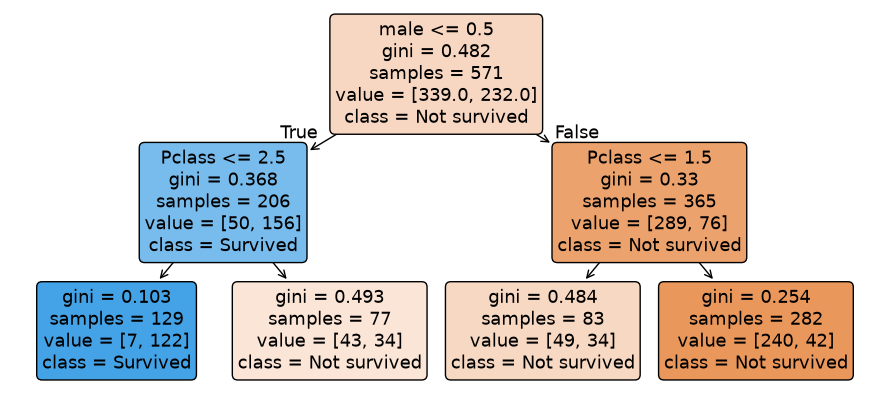

Predicted classes: [0 1]
P(survived): [0.149 0.946]


In [4]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
plt.figure(figsize=(11, 5))
plot_tree(tree, feature_names=list(X.columns),
          class_names=['Not survived', 'Survived'], filled=True, rounded=True)
plt.show()
new_passengers = pd.DataFrame({'Age': [30, 30], 'Fare': [10, 80],
                               'Pclass': [3, 1], 'male': [1, 0]})
print('Predicted classes:', tree.predict(new_passengers))
print('P(survived):', tree.predict_proba(new_passengers)[:, 1].round(3))

**Answer:** The man is predicted "not survived" (P = 0.149) and the woman "survived" (P = 0.946).

- **Root:** male ≤ 0.5? This separates women (left) from men (right).
- **Passenger 1** (man, 3rd class): men → Pclass ≤ 1.5? No → leaf with 240 non-survivors and 42 survivors. P(survived) = 42 / 282 ≈ 0.149.
- **Passenger 2** (woman, 1st class): women → Pclass ≤ 2.5? Yes → leaf with 7 non-survivors and 122 survivors. P(survived) = 122 / 129 ≈ 0.946.
- The other two leaves: women in 3rd class survived in 34 of 77 cases (0.44), and men in 1st class in 34 of 83 cases (0.41). Both are below 0.5, so both leaves predict "not survived".
- At depth 2, the tree uses only sex and class; age and fare are not used.
- A class label summarises the probability. Even "survived" with 0.946 does not mean certainty: 7 of these 129 women died.

## 4. See the effect of pruning

The demonstration is supplied. Which setting creates fewer leaves? Why is the higher training accuracy not enough to select the tree?

In [5]:
for alpha in [0.0, 0.01]:
    pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    pruned.fit(X_train, y_train)
    print('alpha:', alpha, 'leaves:', pruned.get_n_leaves(),
          'training accuracy:', round(pruned.score(X_train, y_train), 3))

alpha: 0.0 leaves: 136 training accuracy: 0.988
alpha: 0.01 leaves: 5 training accuracy: 0.8


**Answer:** alpha = 0.01 creates far fewer leaves: 5 instead of 136.

- The unpruned tree (alpha = 0) reaches 98.8% training accuracy with 136 leaves. Many leaves contain only a few passengers, so the tree has nearly memorised the training rows.
- The pruned tree reaches 80.0% training accuracy with only 5 leaves, which is easy to describe.
- The 131 extra leaves raise training accuracy by 18.8 percentage points, but much of that is fitted noise and will not carry over to new passengers.
- The higher training accuracy is therefore not enough to select the tree. Complexity must be chosen with validation, such as CV.

## 5. Compare forest and boosting with CV

The models and CV are provided. Explain which ensemble averages independently built trees and which adds corrections sequentially. Compare CV AUC.

In [6]:
forest = RandomForestClassifier(n_estimators=100, random_state=42)
boosting = GradientBoostingClassifier(n_estimators=100, max_depth=2,
                                     learning_rate=0.1, random_state=42)
for name, model in [('Forest', forest), ('Boosting', boosting)]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    print(name, 'CV AUC:', round(scores.mean(), 3))

Forest CV AUC: 0.871


Boosting CV AUC: 0.861


**Answer:** The random forest builds its trees independently and averages them; boosting adds small trees one after another as corrections.

- **Forest:** 100 trees, each fitted on a bootstrap sample with random inputs at each split; their probabilities are averaged.
- **Boosting:** 100 trees of depth 2; each new tree corrects the errors that remain after the previous trees.
- **CV AUC:** forest 0.871, boosting 0.861. The forest ranks survivors slightly better on these validation folds.
- The difference of 0.010 is small. Another split or other settings could change the order.
- This does not establish that one method is best for all data.

## 6. Run the supplied search

Run this complete example. We use `max_features="sqrt"` versus `1.0` (all inputs). With our four inputs, a setting of 0.5 would also consider two inputs, exactly like sqrt; using 1.0 makes the comparison distinct. What are the chosen settings? How many setting combinations were tried? Why does the final confusion matrix use a threshold?

In [7]:
grid = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42),
    {'max_features': ['sqrt', 1.0], 'min_samples_leaf': [1, 5, 20]},
    cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)
print('Chosen settings:', grid.best_params_)
print('Best CV AUC:', round(grid.best_score_, 3))
p = grid.predict_proba(X_test)[:, 1]
print('Final test AUC:', round(roc_auc_score(y_test, p), 3))
print('Final confusion matrix:')
print(confusion_matrix(y_test, p >= 0.5, labels=[0, 1]))

Chosen settings: {'max_features': 'sqrt', 'min_samples_leaf': 1}
Best CV AUC: 0.871
Final test AUC: 0.828
Final confusion matrix:
[[71 14]
 [15 43]]


**Answer:** The chosen settings are `max_features="sqrt"` and `min_samples_leaf=1`.

- **Combinations:** 2 values of `max_features` × 3 values of `min_samples_leaf` = 6 combinations. Each is evaluated in 5 folds, so 30 forests are fitted, plus one final refit on all training rows.
- **Best CV AUC:** 0.871. These are the default settings, so the result equals the forest in step 5.
- **Final test AUC:** 0.828. It is lower than the CV AUC, but it is a single estimate from 143 passengers.
- **Why a threshold:** AUC uses the predicted probabilities, but a confusion matrix needs labels. With threshold 0.5, probabilities of at least 0.5 become "survived".
- **Final confusion matrix:** TN = 71, FP = 14, FN = 15, TP = 43.
- **Accuracy:** (71 + 43) / 143 = 0.797.
- **Recall:** 43 / 58 = 0.741, so about three in four survivors are found.
- **Precision:** 43 / 57 = 0.754, so about three in four "survived" predictions are correct.

### Jupyter notebook — footer info

Include this information when submitting your notebook.

In [8]:
import platform
from datetime import datetime
print(platform.platform())
print("Python:", platform.python_version())
print("Date:", datetime.now().isoformat(timespec="seconds"))

Linux-6.8.0-1064-azure-x86_64-with-glibc2.41
Python: 3.11.16
Date: 2026-10-02T20:17:20
